## UMAP

In [ ]:
import pandas as pd
import numpy as np
import umap

def apply_umap(file_infos):
    np.random.seed(42)
    
    all_latents, dataset_name, opacity = [], [], []
    sequences, sequences_type, colors_type, colors_class = [], [], [], []
    markers, sizes_pts, entry_indices = [], [], []
    label_boundaries, label_names, target_label = [], [], []
    
    def get_colors(values, color_or_dict, default='#808080'):
        return [color_or_dict.get(v, default) if isinstance(color_or_dict, dict) else color_or_dict
                for v in values]
        
    for idx, entry in enumerate(file_infos):
        if len(entry) < 8:
            raise ValueError("Each entry must contain at least (path, column_index, label, alpha, colors_dict_type, colors_dict_class, marker, size)")
        
        path, column_index, label, alpha, colors_dict_type, colors_dict_class, marker, size, *ignores = entry
        ignore_list = ignores[0] if ignores else []
        
        df = pd.read_csv(path) if path.endswith('.csv') else pd.read_excel(path)
        latents = df.iloc[:, column_index].apply(
            lambda x: np.fromstring(x.strip("[]"), sep=',') if isinstance(x, str) else np.array(x)
        )
        
        seq = df['Sequence'].tolist()
        
        seq_type = df['Type'].tolist()
        
        # ----------------------
        # Target o 'Average score'
        # ----------------------
        if 'Target' in df.columns:
            seq_class = df['Target'].astype(int).tolist()
        elif 'Average score' in df.columns:
            seq_class = df['Average score'].apply(round).astype(int).tolist()
        else:
            raise ValueError("No 'Target' or 'Average score' column found in the dataframe.")
        
        
        n = len(latents)
        all_latents.extend(latents)
        sequences.extend(seq)
        sequences_type.extend(seq_type)
        dataset_name.extend([label] * n)
        opacity.extend([alpha] * n)
        markers.extend([marker] * n)
        sizes_pts.extend([size] * n)
        entry_indices.extend([idx] * n)
        label_names.append(label)
        label_boundaries.append(n)
        target_label.extend(['AMP' if c == 1 else 'Non-AMP' for c in seq_class])
        
        # --- Colors ---
        colors_type.extend(get_colors(seq_type, colors_dict_type))
        colors_class.extend(get_colors(seq_class, colors_dict_class))
        
    umap_embed = umap.UMAP(
        n_components=2, n_neighbors=100, min_dist=0.25,
        random_state=42, metric='euclidean'
    ).fit_transform(np.vstack(all_latents))
    
    df_plot = pd.DataFrame({
        "UMAP1": umap_embed[:, 0],
        "UMAP2": umap_embed[:, 1],
        "Dataset": dataset_name,
        "Alpha": opacity,
        "Color Type": colors_type,
        "Color Class": colors_class,
        "Target": target_label,
        "Marker": markers,
        "Size": sizes_pts,
        "EntryIndex": entry_indices,
        "Sequences": sequences,
        "Sequence Type": sequences_type
    })

    return df_plot


# Plotting UMAP

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import umap


def plot_umap(df_plot, title):
    fig = go.Figure()

    # Agrupar por 'EntryIndex'
    for entry_idx in df_plot['EntryIndex'].unique():
        df_subset = df_plot[df_plot['EntryIndex'] == entry_idx]
        
        fig.add_trace(go.Scattergl(
            x=df_subset['UMAP1'],
            y=df_subset['UMAP2'],
            mode='markers',
            name=df_subset['Dataset'].iloc[0],
            marker=dict(
                color=df_subset['Color Class'], #TODO Color Type or Color Class
                size=df_subset['Size'],
                symbol=df_subset['Marker'].iloc[0],
                opacity=df_subset['Alpha'].iloc[0]
            ),
            text=df_subset.apply(lambda row: f"Dataset: {row['Dataset']}<br>Sequence: {row['Sequences']}<br>Sequence Type: {row['Sequence Type']}<br>Activity: {row['Target']}", axis=1),
            hoverinfo='text'
        ))
    
    fig.update_layout(  title=title,
                        plot_bgcolor='white',
                        width=800,  # por ejemplo, 800 píxeles de ancho
                        height=600  # por ejemplo, 600 píxeles de alto
                        )
    
    # Mostrar figura
    fig.show()

    # Crear nombre del archivo en minúsculas y con guiones bajos
    filename = title.lower().replace(' ', '_') + '.html'
    
    # Guardar la figura como archivo HTML
    fig.write_html(filename)
    print(f"Archivo guardado como: {filename}")

In [ ]:
df_umap = apply_umap([
(
    'AmpHGT_training_sequences_NCAA_CAA_labeled.xlsx',
    7, # index latents vector
    'AmpHGT Training Dataset',
    0.8,
    {"Seq. with NCAA": "#316886", "Seq. with CAA": "#D9D9D9"},# type colors
    {1: "#D3E171", 0: "#F2BAA9"},# class colors
    'circle',
    6
)
])


In [ ]:
plot_umap(df_umap, title= 'AmpHGT prediction training validation set AMP vs nonAMP')

In [ ]:
df_umap_ncaa = apply_umap([
(
    'AmpHGT_training_sequences_NCAA_CAA_labeled.xlsx',
    7, # index latents vector
    'AmpHGT Training Dataset',
    0.8,
    {"Seq. with NCAA": "#316886", "Seq. with CAA": "#D9D9D9"},# type colors
    {1: "#D3E171", 0: "#F2BAA9"},# class colors
    'circle',
    6
),
(
    'AmpHGT_NCAA_only.xlsx',
    7, # index latents vector
    'AmpHGT Training Dataset',
    0.8,
    "#316886",# type colors
    "#316886",# class colors
    'circle',
    9
)
])

In [ ]:
plot_umap(df_umap_ncaa, title= 'AmpHGT prediction training validation set NCAA vs CAA')

In [ ]:
df_umap_random_peptides_length_5_30_100 = apply_umap([
    (
        'random_peptides_L_length_5_30_100_label.xlsx', 
        6, 'L version', 0.8,
        {"Seq. with NCAA": "#316886", "Seq. with CAA": "#D9D9D9"},
        '#A6B727',
        'circle',
        7
    ),
    (
        'random_peptides_D_length_5_30_100_label.xlsx',
        6, 'D version', 0.8,
        {"Seq. with NCAA": "#316886", "Seq. with CAA": "#D9D9D9"},
        '#F69200',
        'circle',
        7
    ),
    (
        'random_peptides_peptoids_length_5_30_100_label.xlsx',
        6, 'Peptoid version', 0.8,
        {"Seq. with NCAA": "#316886", "Seq. with CAA": "#D9D9D9"},
        '#418AB3',
        'circle',
        7
    ),
        (
        'random_peptides_L_length_5_30_100_label_#5.xlsx', 
        6, 'L version', 0.8,
        {"Seq. with NCAA": "#316886", "Seq. with CAA": "#D9D9D9"},
        '#A6B727',
        'circle',
        15
    ),
    (
        'random_peptides_D_length_5_30_100_label_#5.xlsx',
        6, 'D version', 0.8,
        {"Seq. with NCAA": "#316886", "Seq. with CAA": "#D9D9D9"},
        '#F69200',
        'circle',
        15
    ),
    (
        'random_peptides_peptoids_length_5_30_100_label_#5.xlsx',
        6, 'Peptoid version', 0.8,
        {"Seq. with NCAA": "#316886", "Seq. with CAA": "#D9D9D9"},
        '#418AB3',
        'circle',
        15
    ),
])


In [ ]:
plot_umap(df_umap_random_peptides_length_5_30_100, title= 'Random Peptides L vs D')

# Ecludian Distances Embeddings

Euclidean distances added and saved in random_peptides_with_added_distances.xlsx
Histogram: Distance L vs D:
  Minimum: 3.623
  Maximum: 17.585
  Mean: 9.556
  Standard Deviation: 3.097



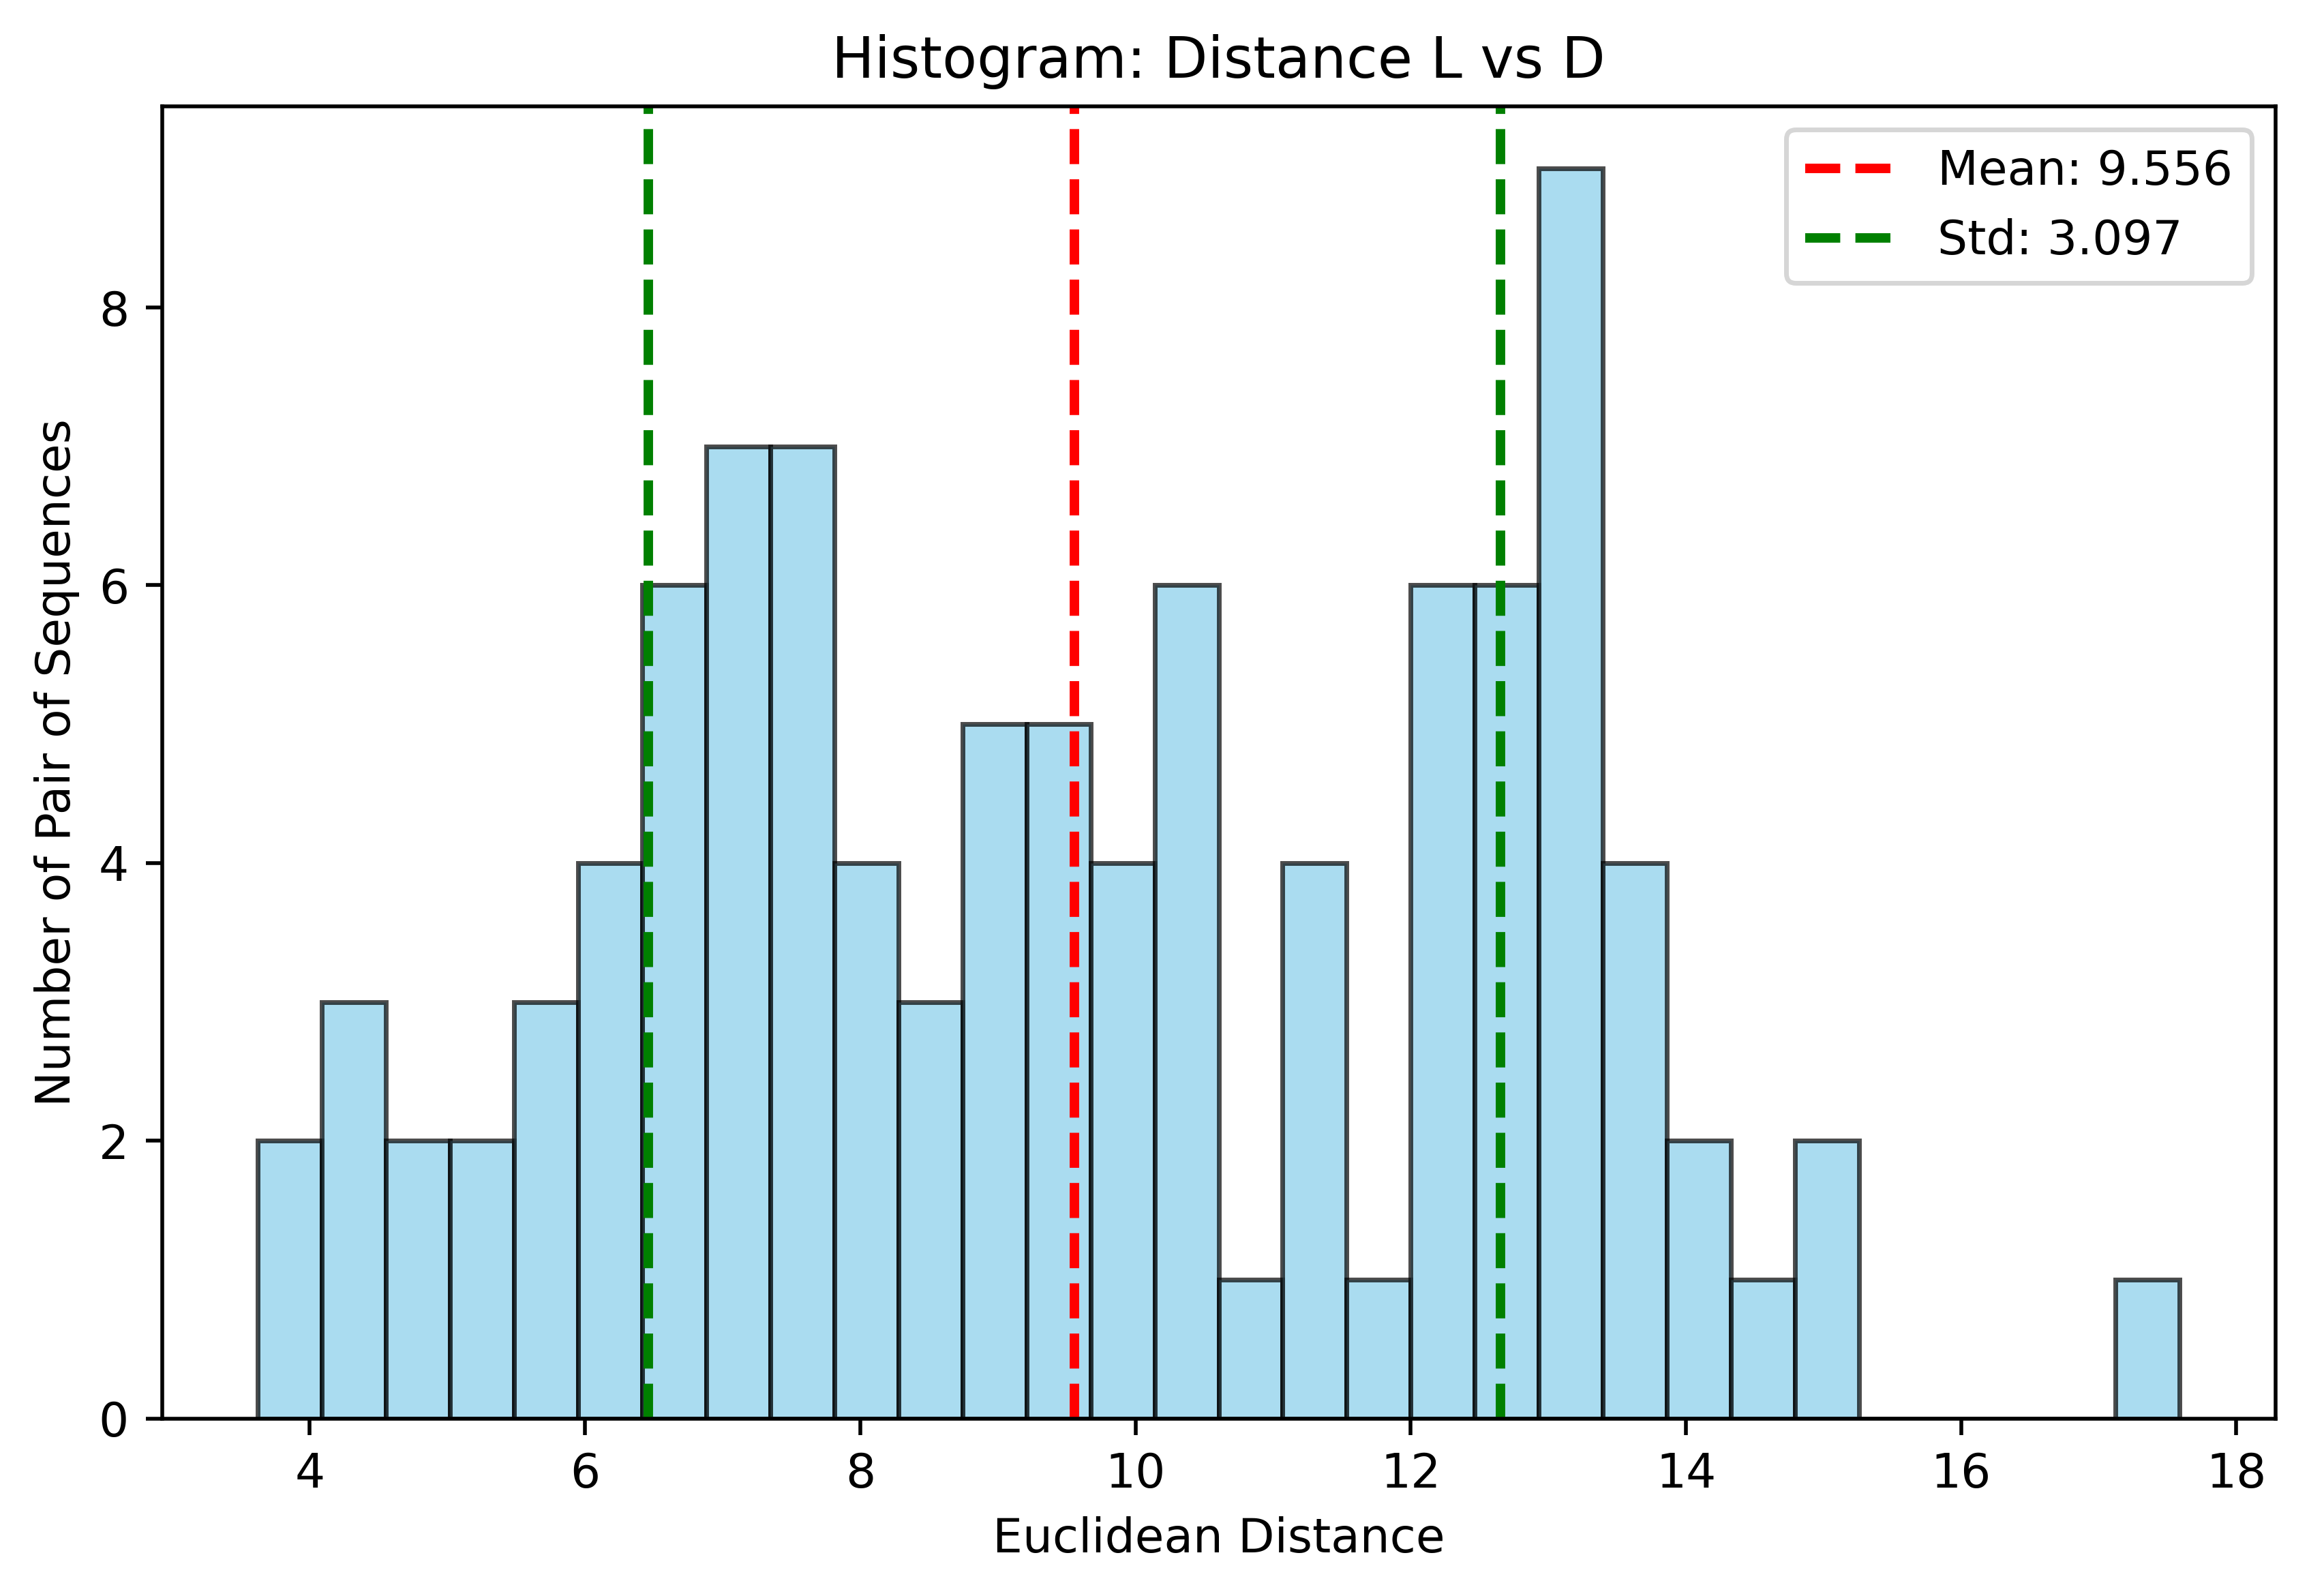

Histogram: Distance L vs Peptoid:
  Minimum: 39.386
  Maximum: 217.937
  Mean: 123.011
  Standard Deviation: 50.381



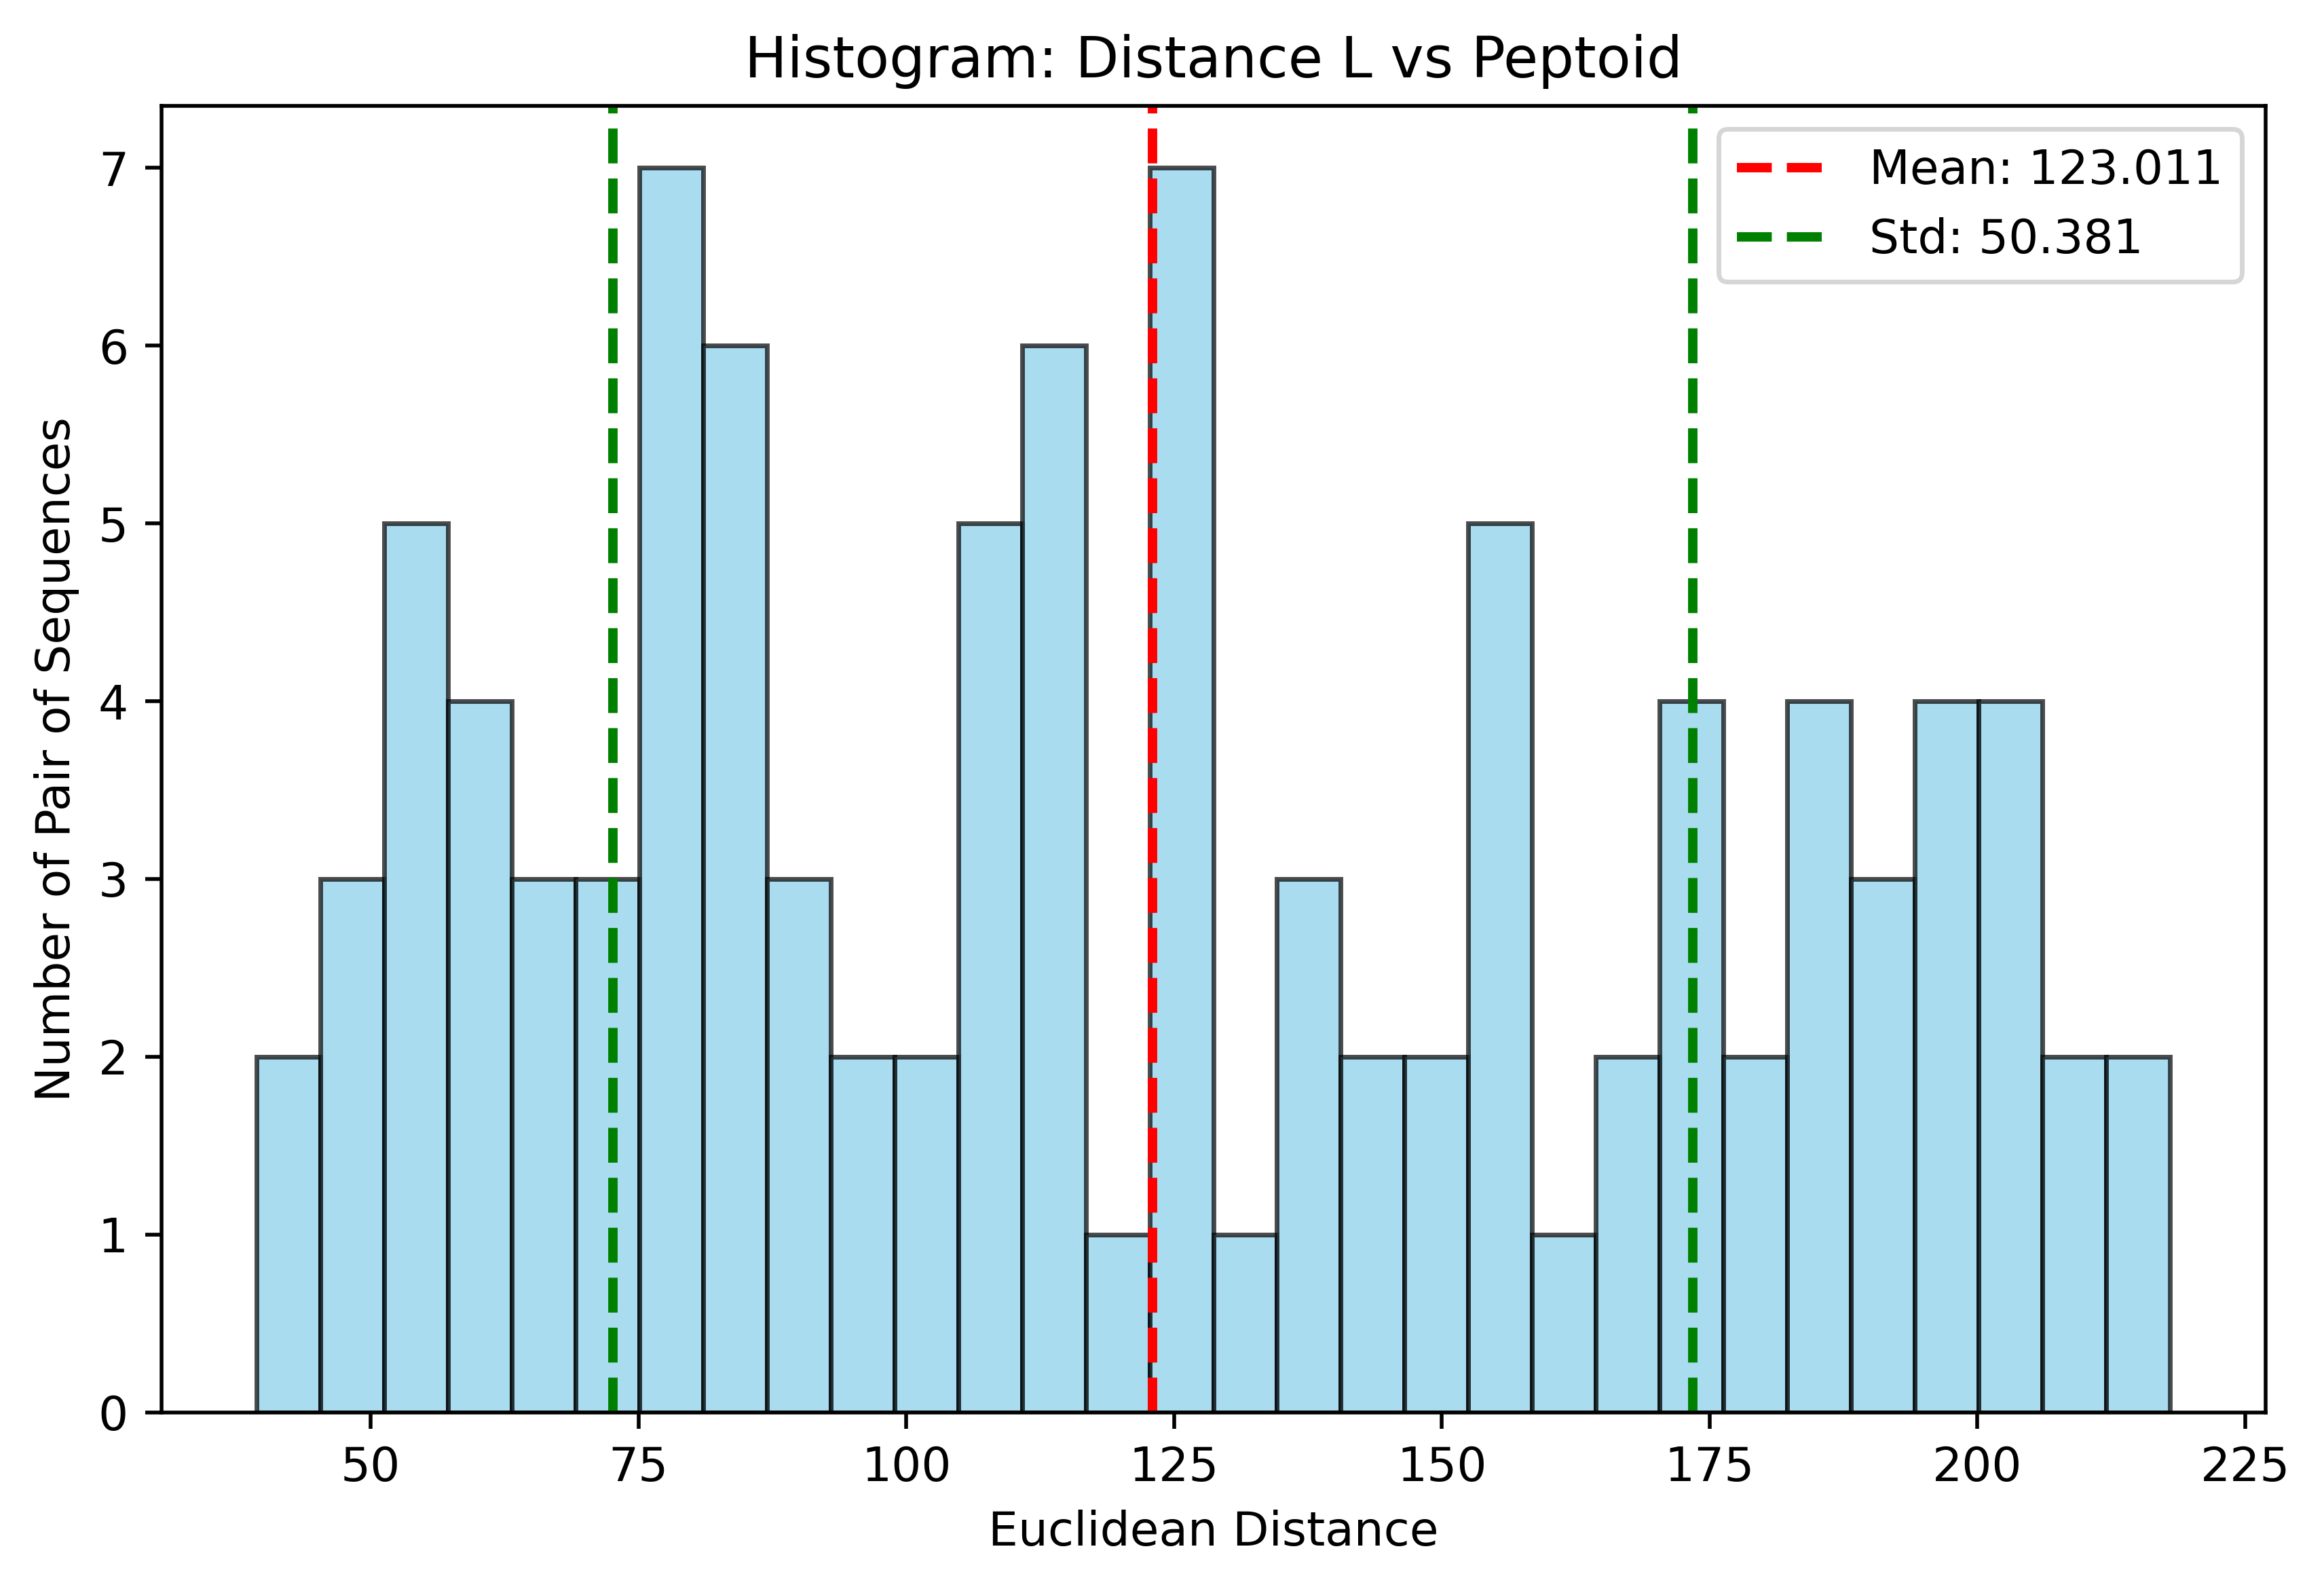

Histogram: Distance D vs Peptoid:
  Minimum: 40.484
  Maximum: 218.697
  Mean: 124.146
  Standard Deviation: 49.996



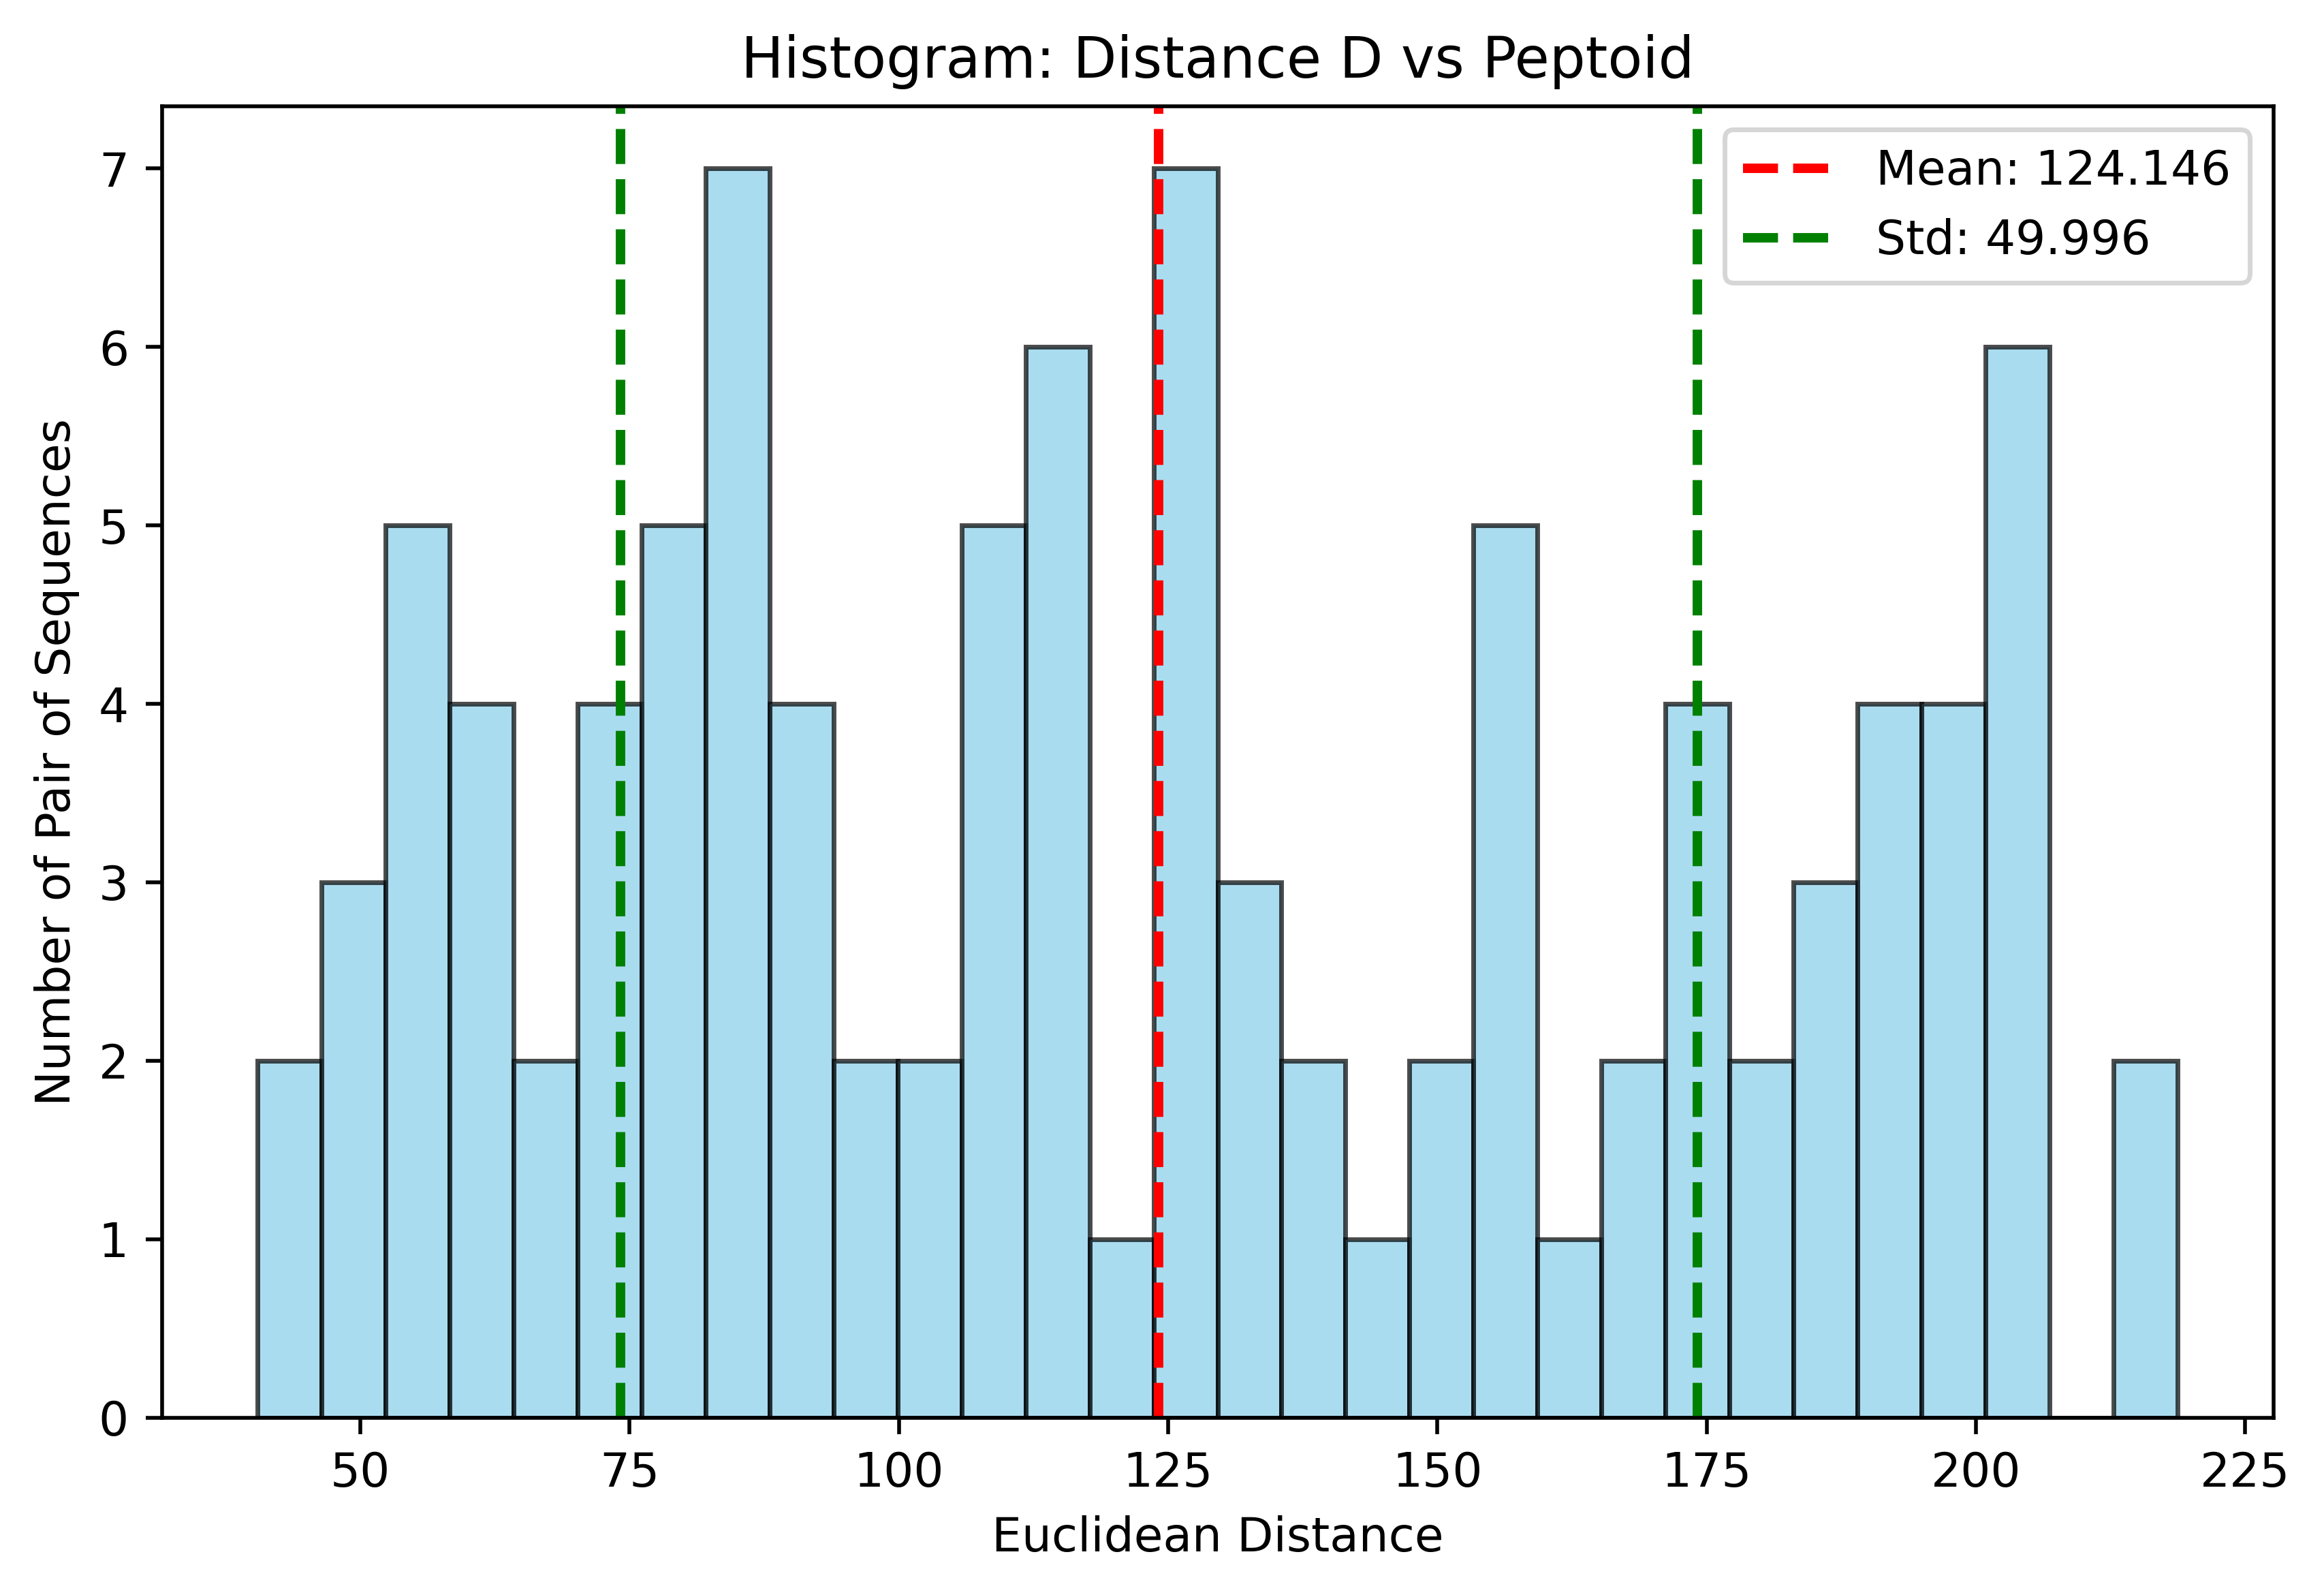

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the Excel file
df = pd.read_excel("random_peptides_L_D_peptoids.xlsx")

# Function to convert strings to numpy arrays if needed
def str_to_list(s):
    return np.array(eval(s))

df['Latent_L'] = df['Latent_L'].apply(str_to_list)
df['Latent_D'] = df['Latent_D'].apply(str_to_list)
df['Latent_peptoids'] = df['Latent_peptoids'].apply(str_to_list)

# Calculate Euclidean distances
df['Distance_L_D'] = df.apply(lambda row: np.linalg.norm(row['Latent_L'] - row['Latent_D']), axis=1)
df['Distance_L_peptoid'] = df.apply(lambda row: np.linalg.norm(row['Latent_L'] - row['Latent_peptoids']), axis=1)
df['Distance_D_peptoid'] = df.apply(lambda row: np.linalg.norm(row['Latent_D'] - row['Latent_peptoids']), axis=1)

# Save the updated DataFrame
df.to_excel("random_peptides_with_added_distances.xlsx", index=False)
print("Euclidean distances added and saved in random_peptides_with_added_distances.xlsx")

# Function to plot histogram with mean, std, min, and max
def plot_histogram(data, title):
    mean_val = np.mean(data)
    std_val = np.std(data)
    min_val = np.min(data)
    max_val = np.max(data)
    
    # Print statistics
    print(f"{title}:")
    print(f"  Minimum: {min_val:.3f}")
    print(f"  Maximum: {max_val:.3f}")
    print(f"  Mean: {mean_val:.3f}")
    print(f"  Standard Deviation: {std_val:.3f}\n")
    
    # Plot histogram
    plt.figure(figsize=(8,5), dpi=500)
    plt.hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Vertical lines for mean and ±1 std
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.3f}')
    plt.axvline(mean_val - std_val, color='green', linestyle='dashed', linewidth=2, label=f'Std: {std_val:.3f}')
    plt.axvline(mean_val + std_val, color='green', linestyle='dashed', linewidth=2)
    
    plt.xlabel('Euclidean Distance')
    plt.ylabel('Number of Pair of Sequences')
    plt.title(title)
    plt.legend()
    plt.show()

# Plot the three histograms
plot_histogram(df['Distance_L_D'], 'Histogram: Distance L vs D')
plot_histogram(df['Distance_L_peptoid'], 'Histogram: Distance L vs Peptoid')
plot_histogram(df['Distance_D_peptoid'], 'Histogram: Distance D vs Peptoid')


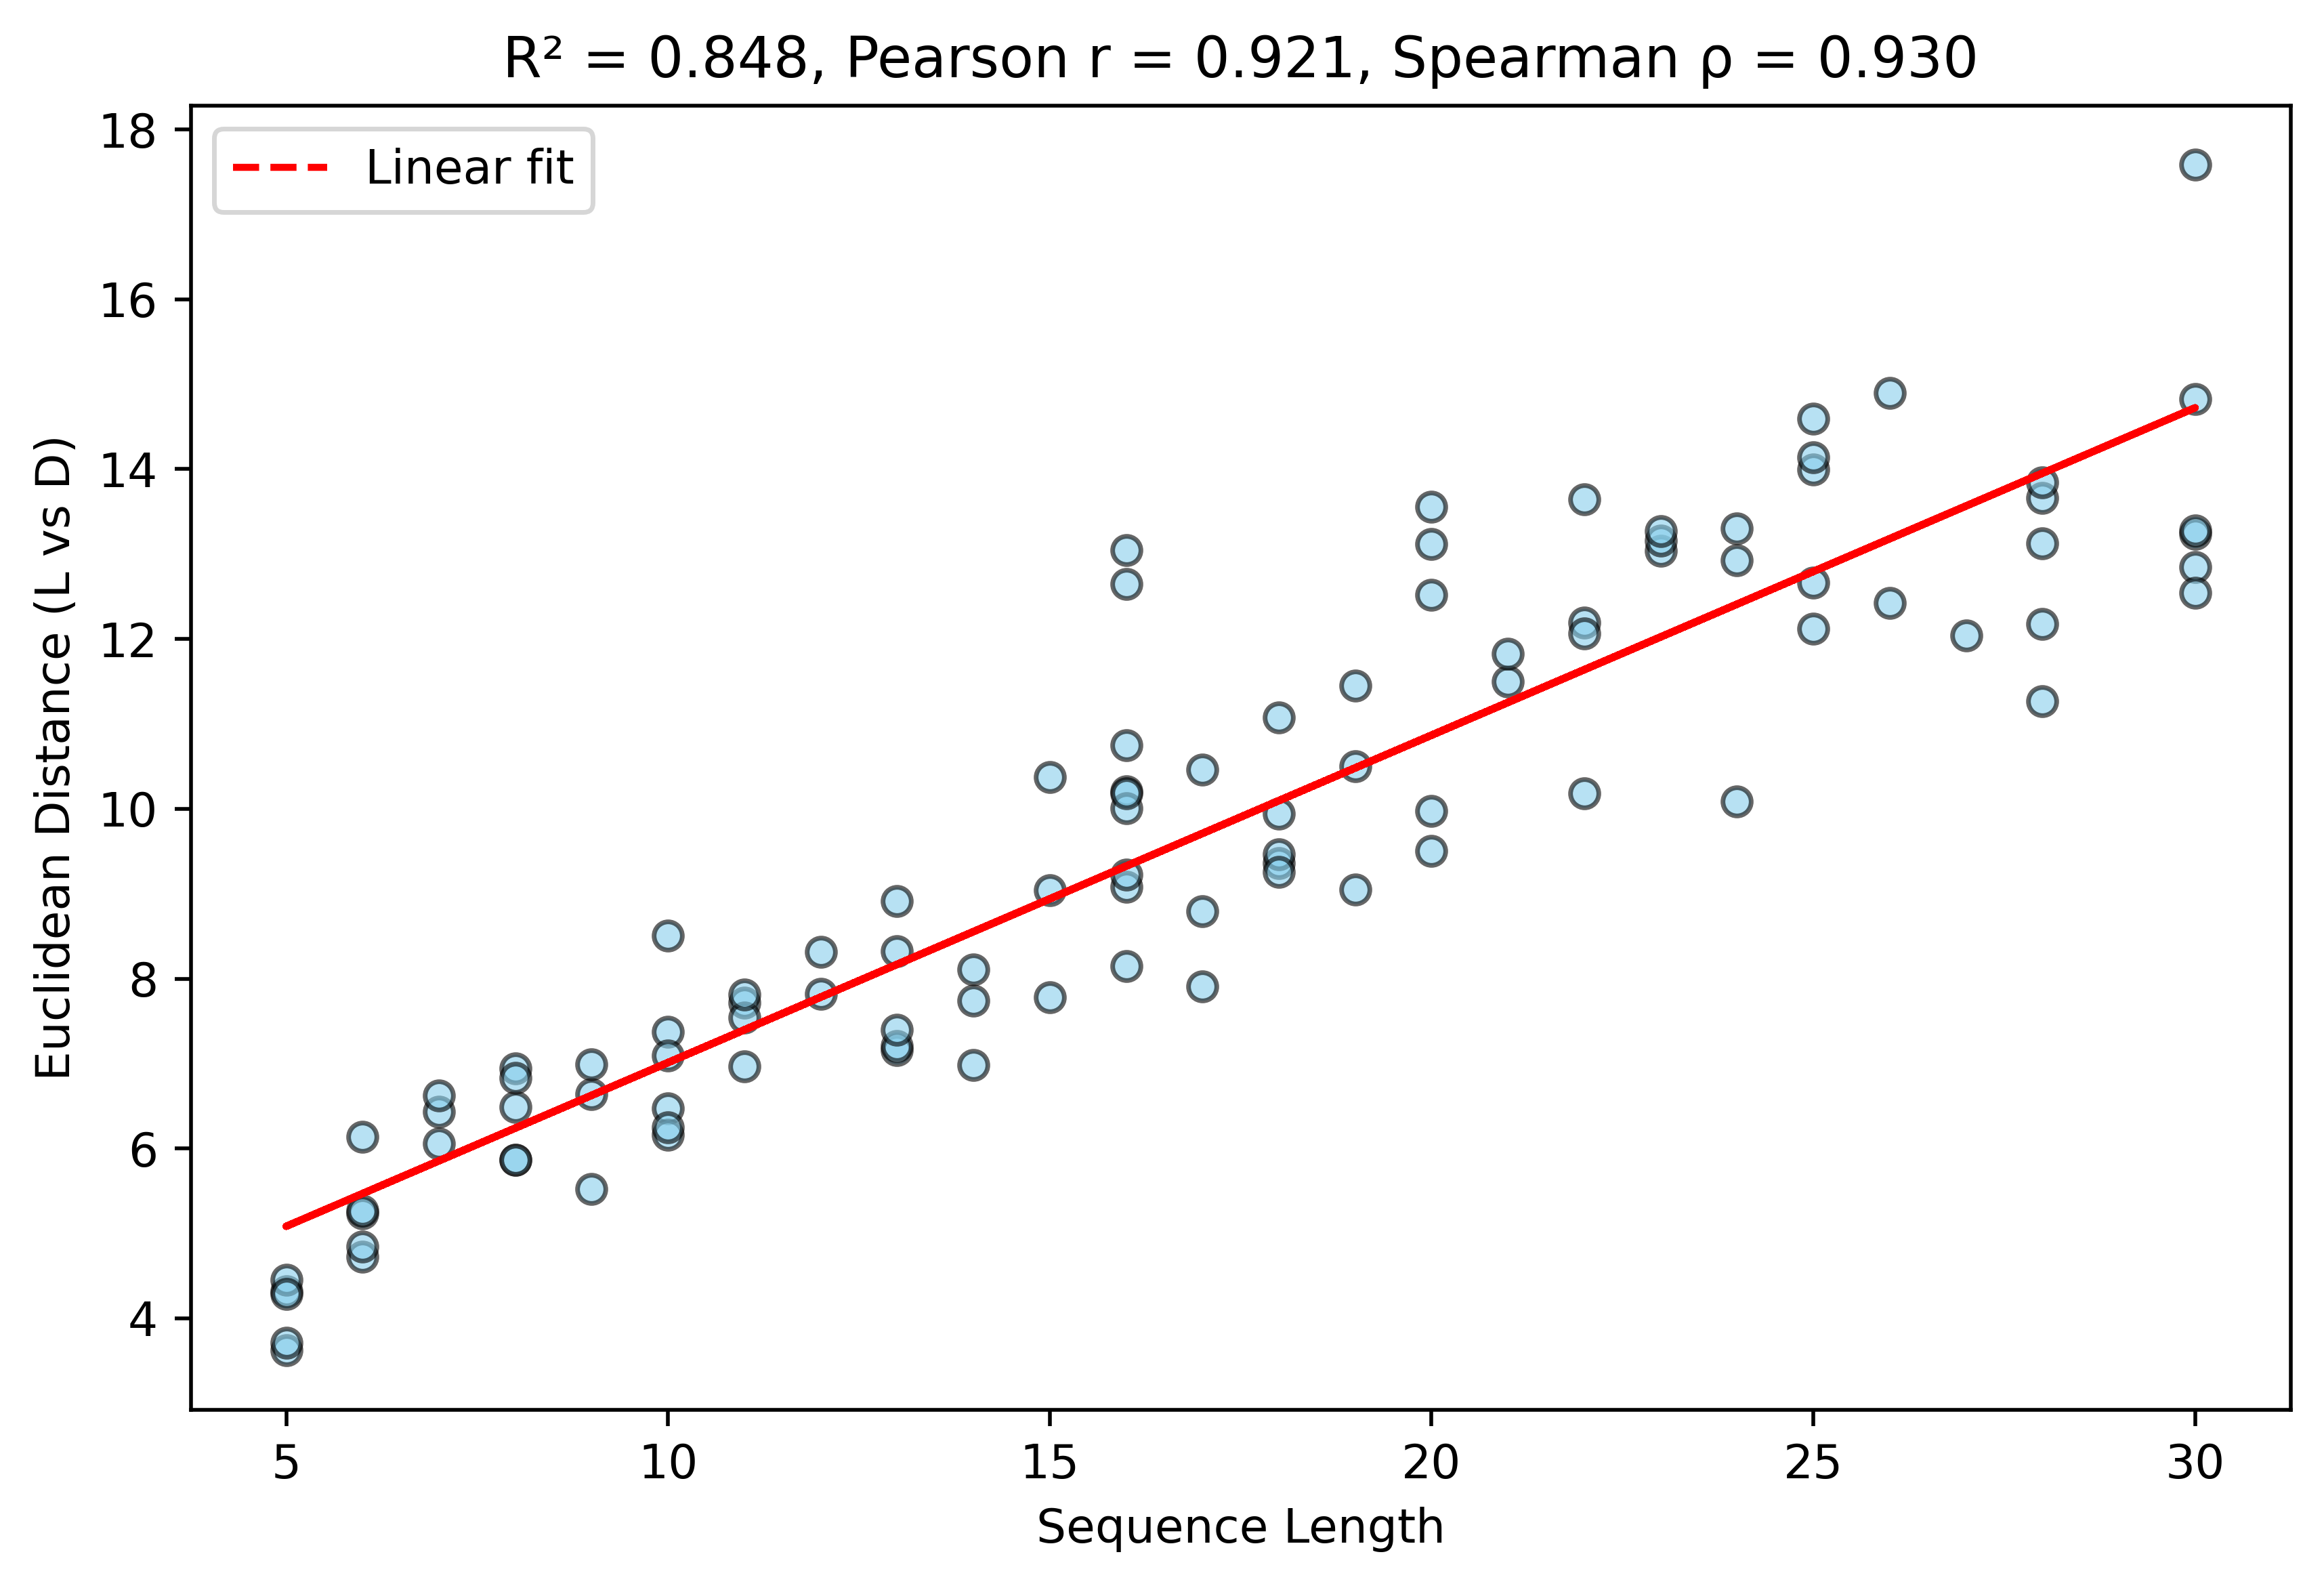

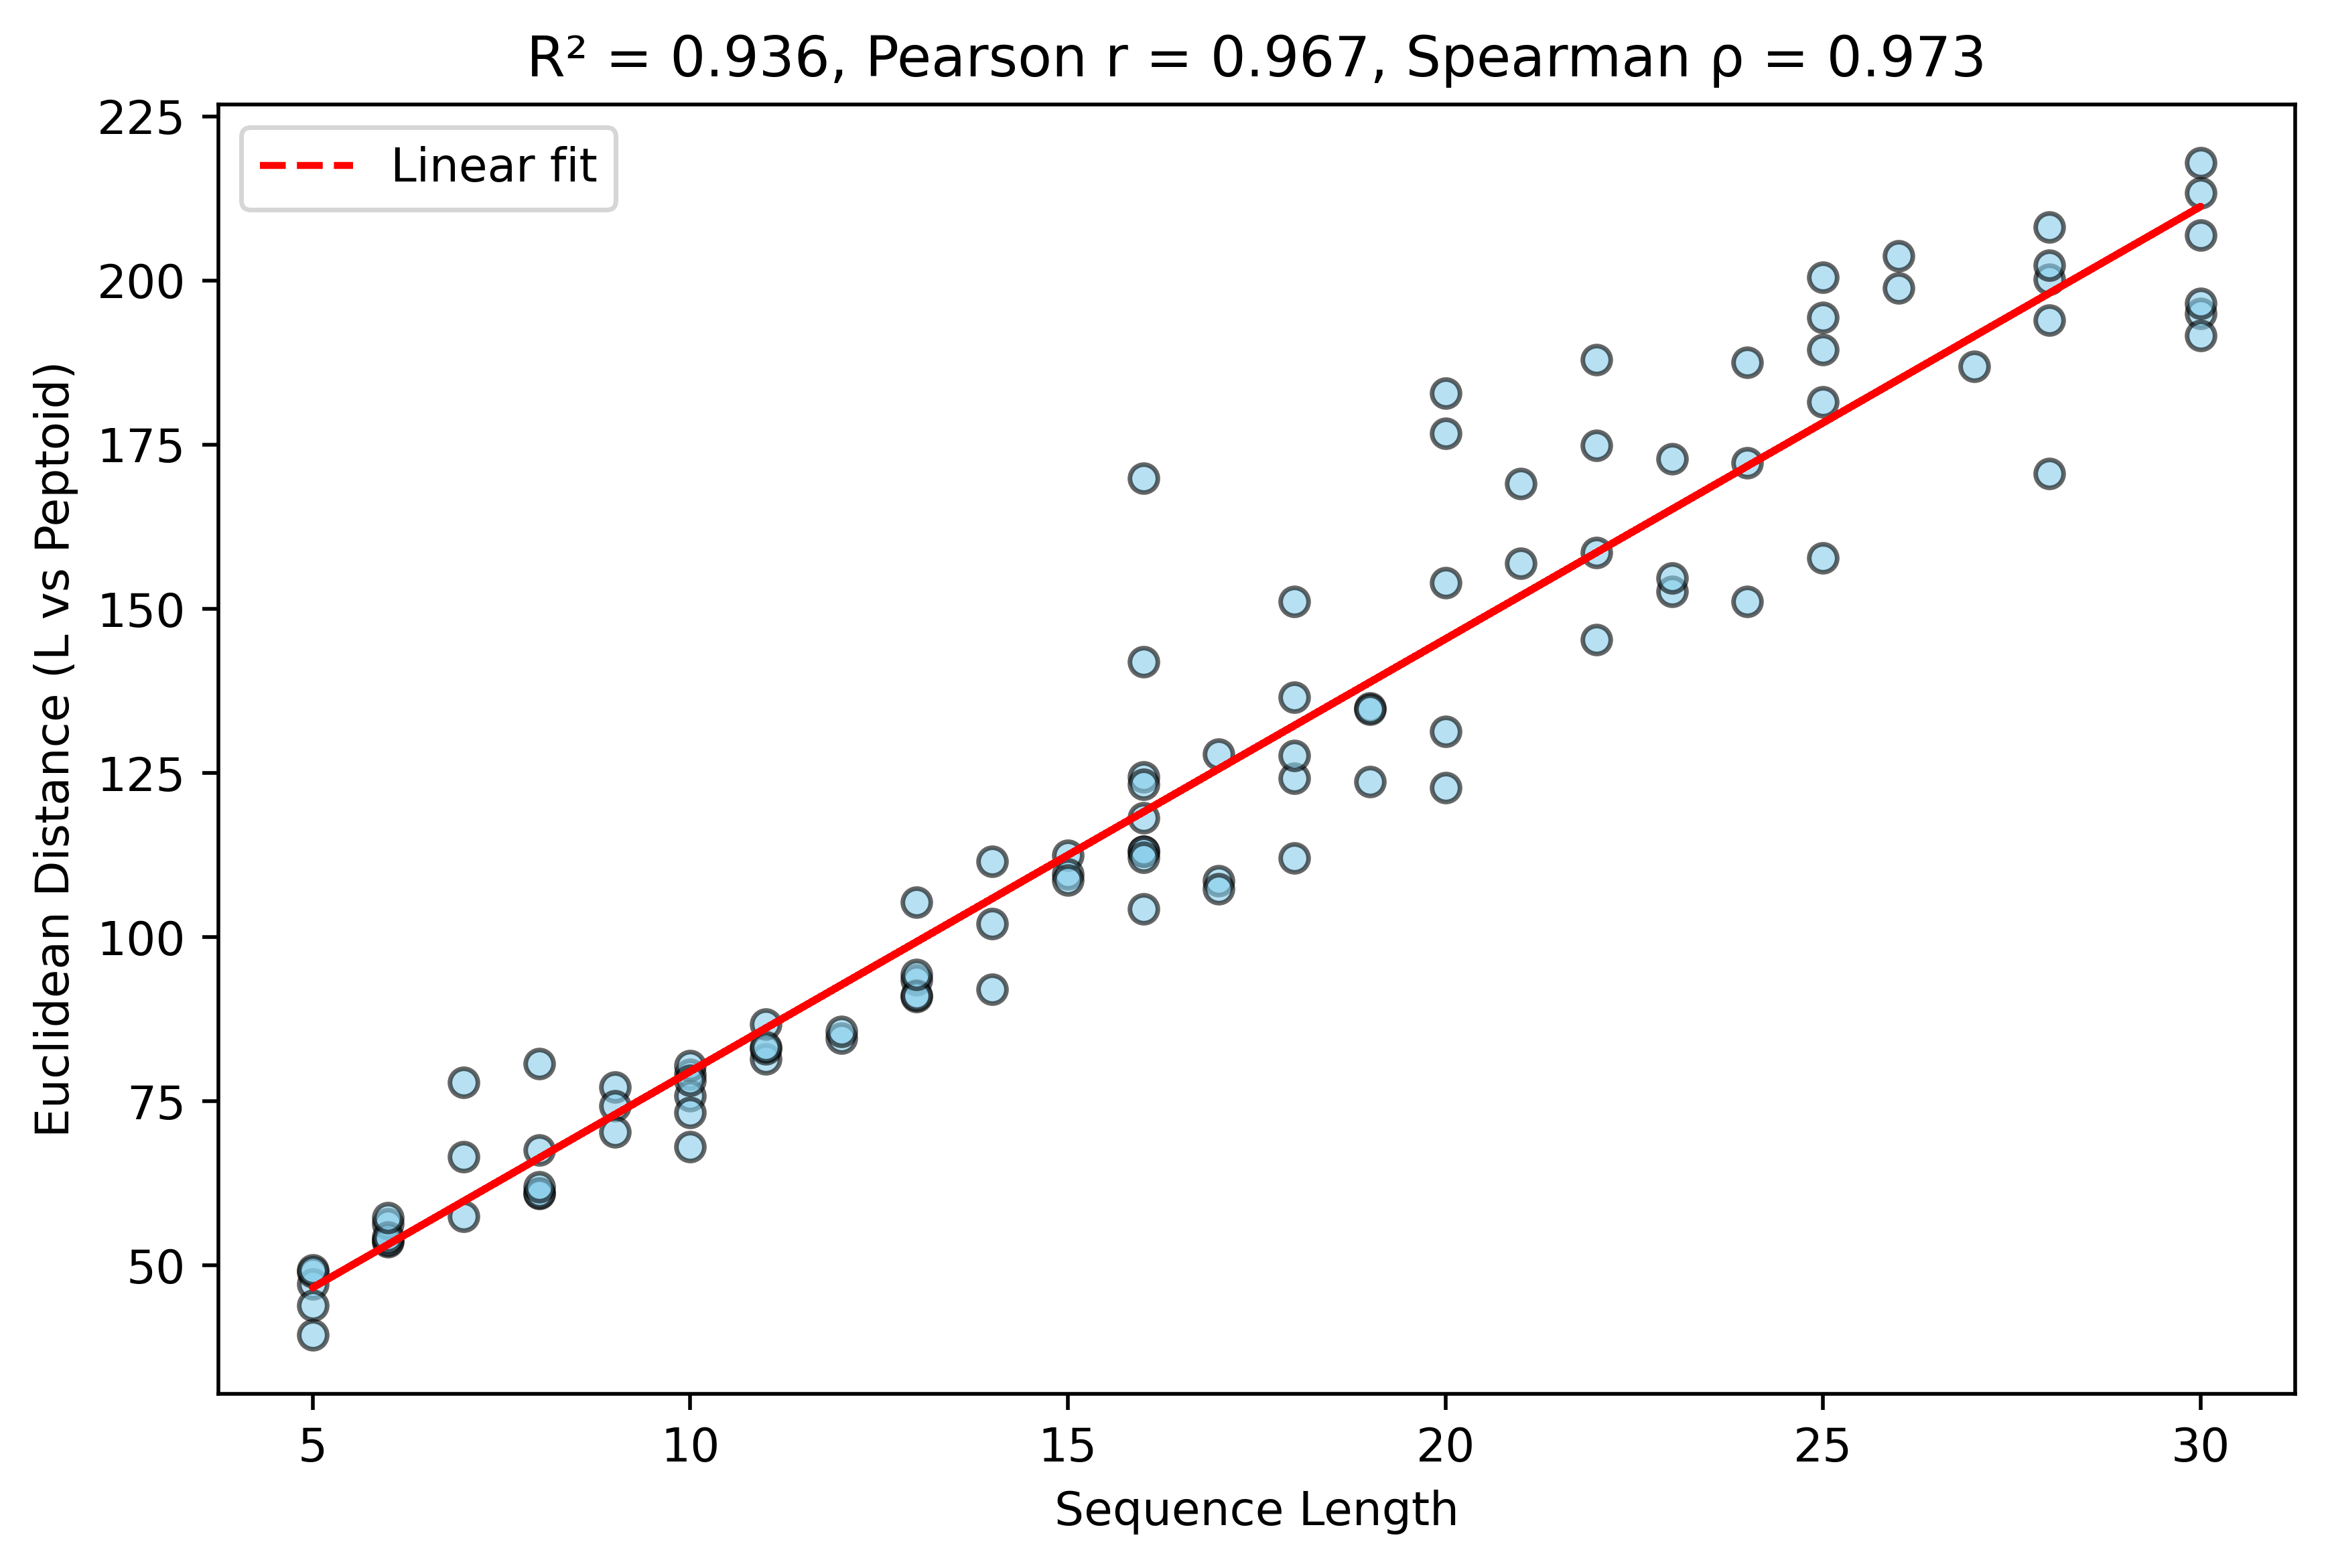

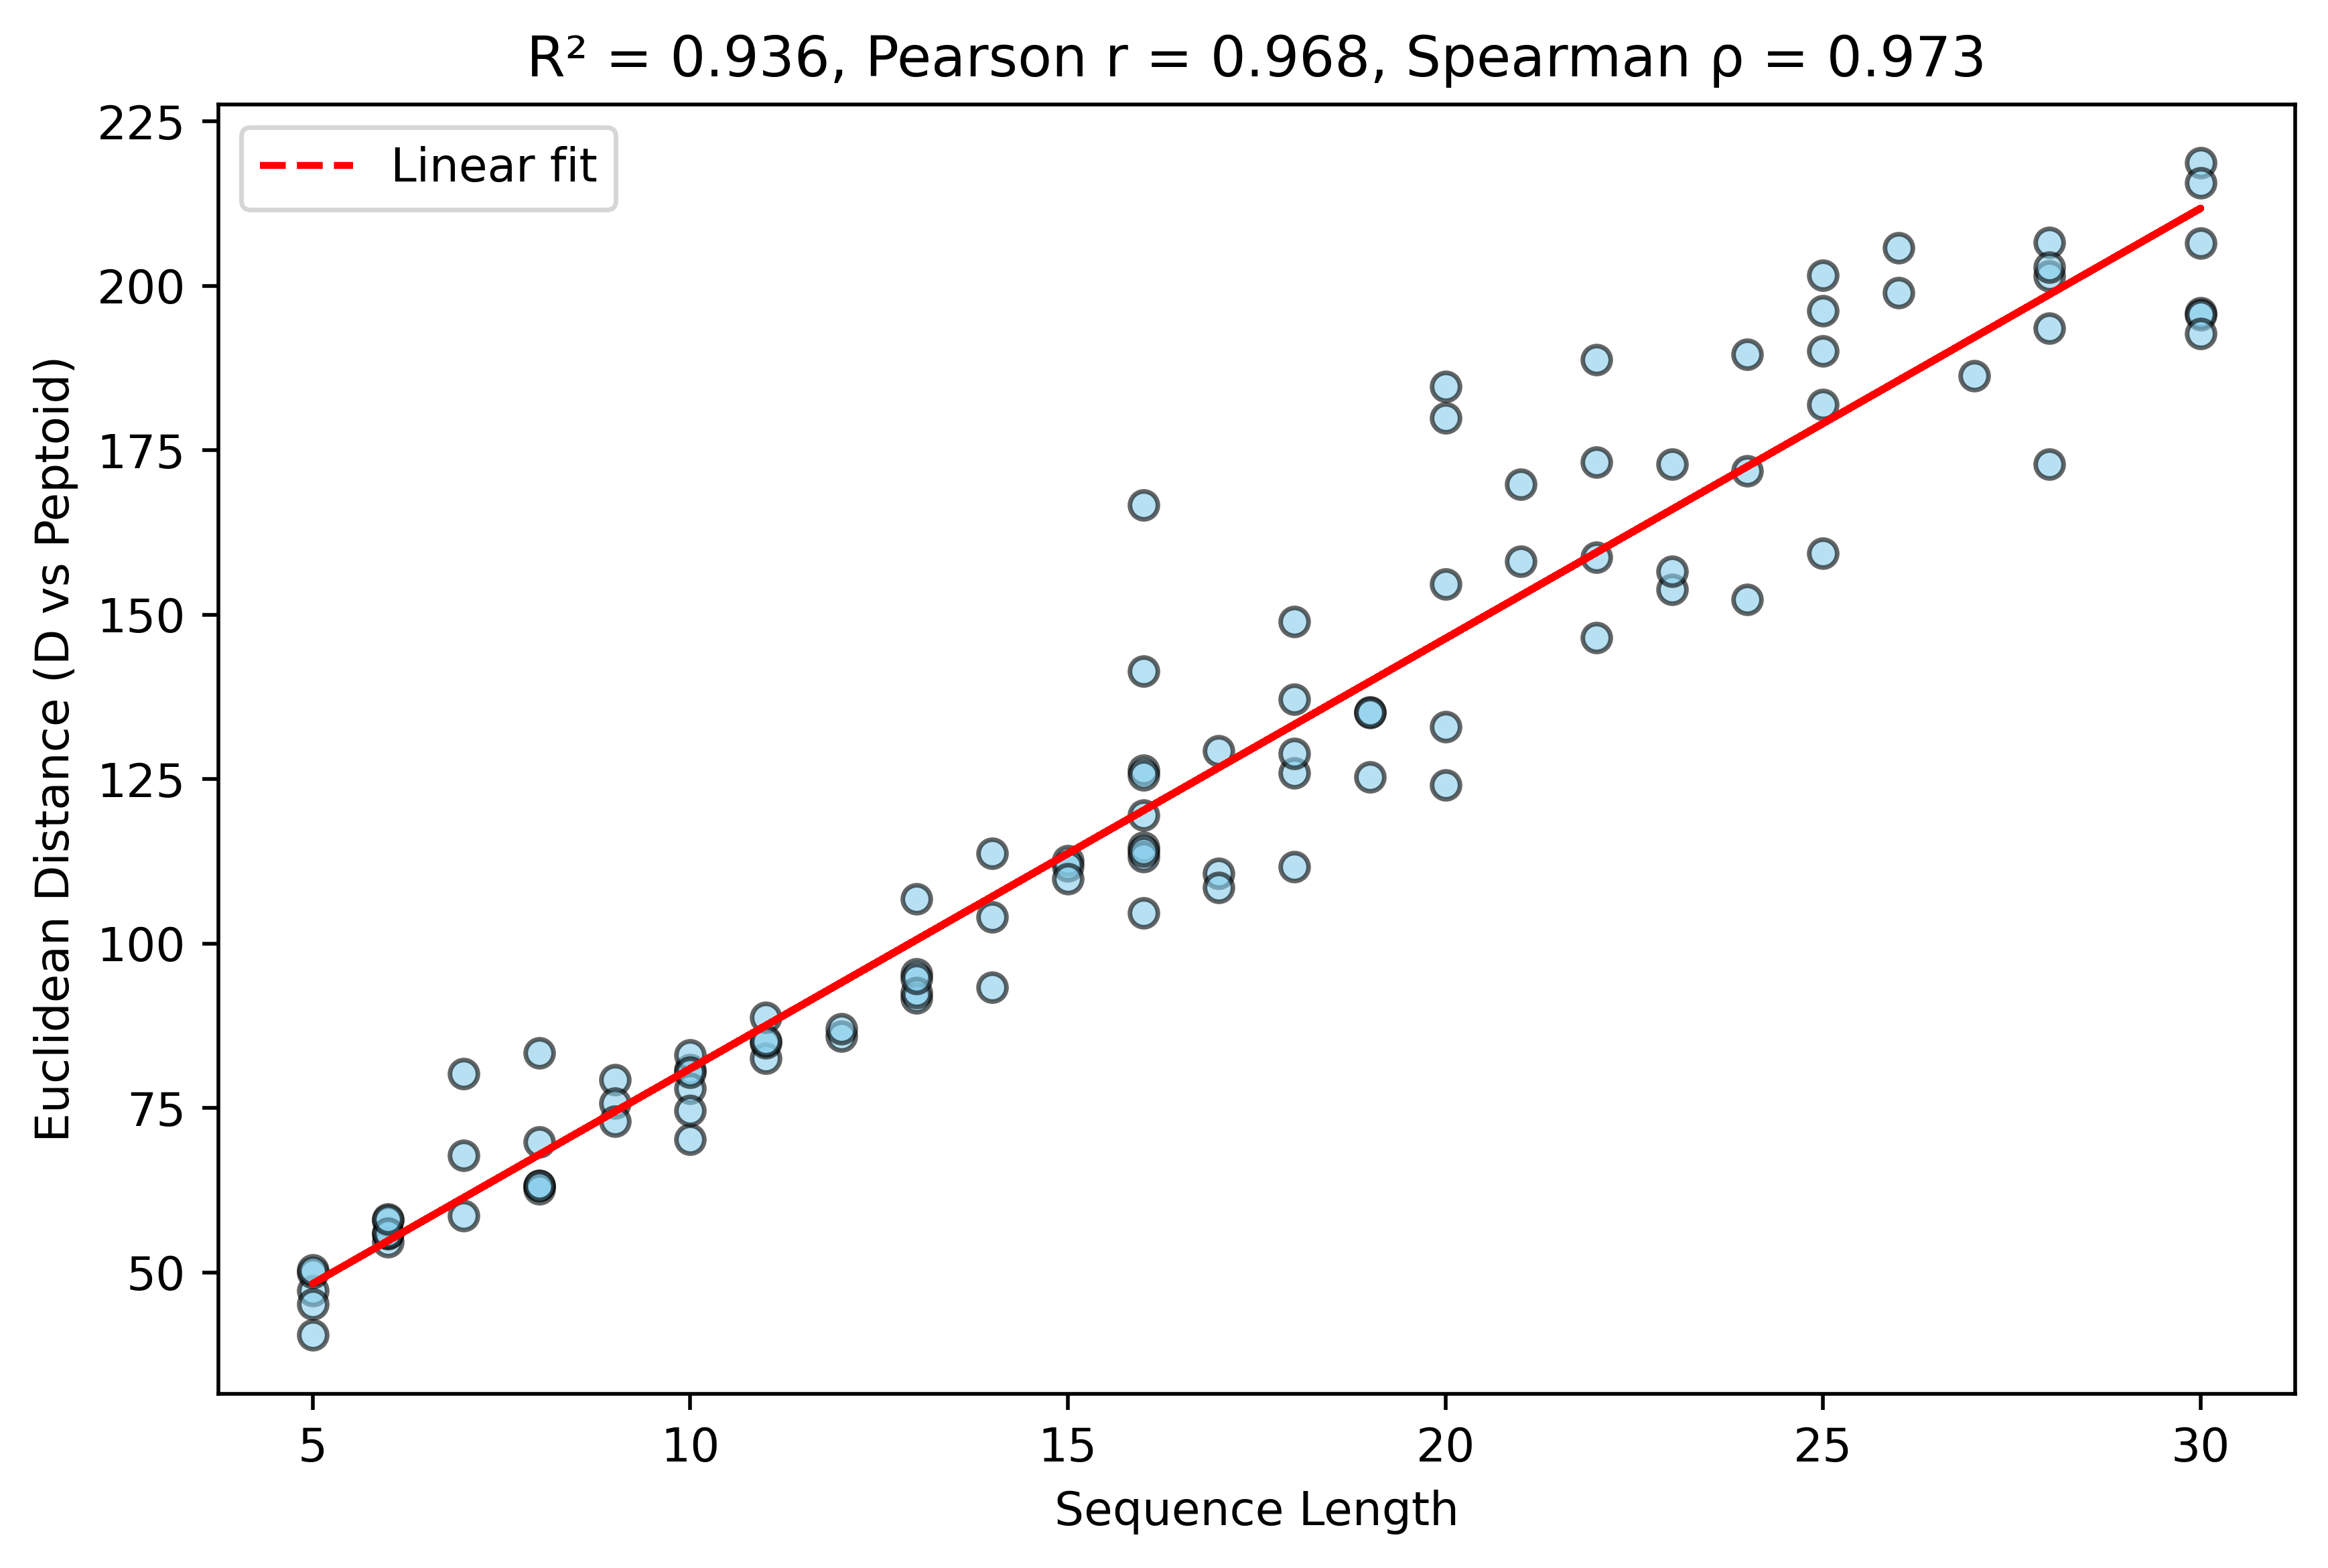

In [10]:
# Function to create scatter plot with Pearson r, Spearman ρ, and R²
def scatter_plot_length_vs_distance(df, distance_col, x_label='Sequence Length', y_label=None, title=None):
    x = df['Sequence_L_length'].values.reshape(-1,1)
    y = df[distance_col].values
    
    # Linear regression for R²
    model = LinearRegression()
    model.fit(x, y)
    r2 = model.score(x, y)
    
    # Pearson correlation
    pearson_corr, _ = pearsonr(x.flatten(), y)
    
    # Spearman correlation
    spearman_corr, _ = spearmanr(x.flatten(), y)
    
    # Default y_label
    if y_label is None:
        y_label = distance_col
    
    # Default title
    if title is None:
        title = f'R² = {r2:.3f}, Pearson r = {pearson_corr:.3f}, Spearman ρ = {spearman_corr:.3f}'
    
    plt.figure(figsize=(8,5), dpi=500)
    plt.scatter(x, y, alpha=0.6, color='skyblue', edgecolor='black')
    
    # Regression line
    plt.plot(x, model.predict(x), color='red', linestyle='--', label='Linear fit')
    
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()
    plt.show()

scatter_plot_length_vs_distance(df, 'Distance_L_D', x_label='Sequence Length', y_label='Euclidean Distance (L vs D)')
scatter_plot_length_vs_distance(df, 'Distance_L_peptoid', x_label='Sequence Length', y_label='Euclidean Distance (L vs Peptoid)')
scatter_plot_length_vs_distance(df, 'Distance_D_peptoid', x_label='Sequence Length', y_label='Euclidean Distance (D vs Peptoid)')
